# First Tutorial: Analyzing Proliferative vs Quiescent Cell States with HarmoCycle using GSE93593 Data



This tutorial demonstrates how to use HarmoCycle to identify proliferative and quiescent cell populations using the GSE93593 dataset from Close et al. 2017 (Neuron).

## Step-by-Step Guide

### 1. Data Preparation

Before running the analysis, ensure your data is properly formatted:

```python
import scanpy as sc
import pandas as pd
import numpy as np

# Load your data
adata = sc.read_h5ad("your_data.h5ad")

# Important: Ensure gene symbols are in .var.index
# HarmoCycle automatically converts all gene names to uppercase for cross-species compatibility
# For mouse data, you may need to convert gene symbols to human orthologs first
```

### 2. Preprocessing Considerations

The HarmoCycle pipeline includes automatic preprocessing steps:

- **log1p transformation**: Applied by default unless disabled
- **Scaling**: Applied by default unless disabled

If your data is already preprocessed, you can disable these steps using command-line arguments.

### 3. Running HarmoCycle

The easiest way to run HarmoCycle is using the provided command-line script:

```bash
python ./HarmoCycle/HarmoCycle_Density_v2.py \
  --input your_data.h5ad \
  --reference ./HarmoCycle/reference_data/ \
  --output ./results/
```

**Important parameters:**
- `--input`: Path to your h5ad file (must have gene symbols as .var.index)
- `--reference`: Path to the reference datasets (provided in the HarmoCycle package)
- `--output`: Directory for results
- `--no-log1p`: Disable log1p transformation if your data is already processed
- `--no-scale`: Disable scaling if your data is already scaled

### 4. Understanding the Reference Data

HarmoCycle uses four purified cell cycle reference datasets, each containing pure cell populations with validated cell cycle trajectories. These references are:

- Pure cell type populations
- Processed through HarmoCycle's cell cycle trajectory inference
- Available in the HarmoCycle GitHub package

**Download reference data:**
The pre-processed reference h5ad files are available at: [Data Link Placeholder]

### 5. Cross-Species Compatibility

To handle different species:

```python
# HarmoCycle automatically converts gene names to uppercase
# For mouse-to-human conversion, consider using:
# - g:Profiler
# - biomaRt
# - Homologene

```

To integrate this into your English GitHub tutorial, you can use the following professional phrasing for the data access section:

## 4. Quick Start: Pre-processed Data
To facilitate the demonstration and ensure a smooth tutorial experience, we provide a pre-processed version of this dataset in **.h5ad** format (compatible with Scanpy and AnnData). This version includes basic quality control and normalization, allowing you to jump straight into the analysis.

You can download the processed file via the link below:
*   **Download Link**: [Link under preparation / Coming soon]

---

**如果您想看这一段在整个文档中的完整排版，可以参考下面这个合并后的版本：**

# Data Description: Single-Cell Transcriptomics of Human hESC-Derived Interneuron Differentiation

## 1. Data Source & Reference
This tutorial utilizes a single-cell RNA-seq (scRNA-seq) dataset from the following study:
*   **Title**: *Single-Cell Profiling of Human iPSC-Derived Progenitors and Differentiated Neurons Reveals Temporal Control of Cell Fate*
*   **Authors**: Close et al.
*   **Journal**: *Neuron* (2017)
*   **GEO Accession**: [GSE93593](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE93593)

## 2. Experimental Background
The study describes a 125-day differentiation protocol designed to convert **H1 human embryonic stem cells (hESCs)** into a variety of ventrally-derived cell types, specifically focusing on **inhibitory interneurons**. 

By ventralizing hESCs *in vitro*, the researchers aimed to mimic the development of the human neural tube. They engineered a **DCX-Citrine/Y** reporter hESC line, which allowed for the fluorescence-activated cell sorting (FACS) of progenitors and neurons. This enabled the separate characterization of transcriptomics at different stages of maturation, providing a high-resolution map of how human interneurons emerge and mature over time.

## 3. Dataset Summary
*   **Sequencing Technology**: Smart-seq2 (Full-length transcript coverage)
*   **Sample Size**: 1,732 single cells
*   **Timepoints**: Data was collected at four key stages of the 125-day protocol: **D24, D54, D100, and D125**.
*   **Key Cell Populations**:
    *   **Progenitors**: Early-stage lateral ganglionic eminence (LGE)-like and medial ganglionic eminence (MGE)-like progenitors.
    *   **Neurons**: MGE-like neuronal populations, including the emergence of **SST-expressing (Somatostatin)** interneurons at later stages.
    *   **Glial Lineages**: Identification of oligodendrocyte and astrocyte progenitors appearing in the late stages of culture.

## 4. Quick Start: Pre-processed Data
To facilitate the demonstration and ensure a smooth tutorial experience, we provide a pre-processed version of this dataset in **.h5ad** format (compatible with Scanpy and AnnData). This version has undergone basic quality control, allowing you to jump straight into the downstream analysis.

You can download the processed file via the link below:
*   **Download Link**: [Link under preparation]

In [2]:
import scanpy as sc
adata1 = sc.read_h5ad('/root/Cycle/Github/Tutorial_Dataset/human_close-2017.h5ad')
adata1

AnnData object with n_obs × n_vars = 1732 × 23045
    obs: 'cell_suspension.provenance.document_id', 'annotated_cell_identity.text', 'annotated_cell_identity.ontology', 'annotated_cell_identity.ontology_label', 'UMI Count', 'Louvain Cluster'
    obsm: 'X_umap'

/root/anaconda3/envs/HT2VEC/envs/CycleAtlas/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


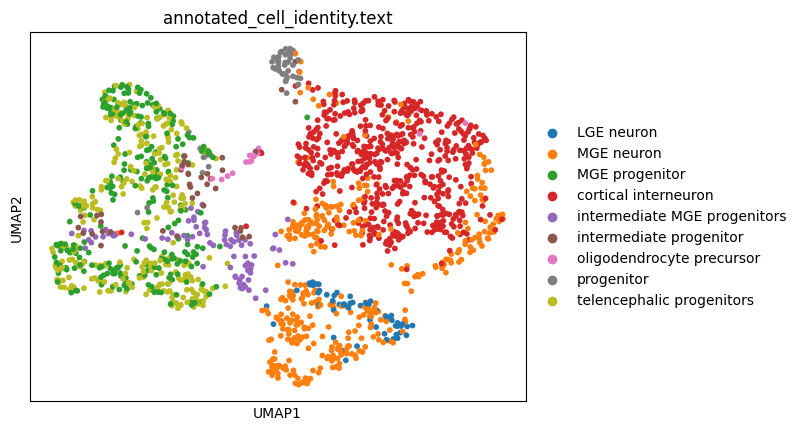

In [3]:

sc.pl.umap(adata1, color='annotated_cell_identity.text')

## 5. Identification of Cycling and Quiescent Cells
As observed in the experimental background, this dataset encompasses multiple cell types at different developmental stages—from early progenitors to mature neurons. Within this population, it is expected that a significant portion of cells (particularly mature neurons) exist in a **quiescent** state, while others (progenitors) are actively **cycling**.


In [4]:
!python /root/Cycle/Github/HarmoCycle/HarmoCycle_Density_v2.py \
    --code_dir '/root/Cycle/Github/HarmoCycle' \
    --data_raw "/root/Cycle/Github/Tutorial_Dataset/human_close-2017.h5ad" \
    --data_meta "/root/Cycle/Github/Tutorial_Dataset/human_close-2017.h5ad" \
    --ref_base_dir /root/Cycle/Github/Experiment/Temp_Result \
    --output_dir /root/Cycle/Github/Tutorial/human_close-2017 \
    --cell_type_key annotated_cell_identity.text \
    --n_gmm 3 \
    --n_prolif 1
    

[INFO] Global seed set to 79710
[INFO] HarmoCycle modules loaded successfully.
[INFO] Parameters saved to /root/Cycle/Github/Tutorial/human_close-2017/run_parameters.json
[PROCESS] Loading data...
  > Raw:  /root/Cycle/Github/Tutorial_Dataset/human_close-2017.h5ad
  > Meta: /root/Cycle/Github/Tutorial_Dataset/human_close-2017.h5ad
[INFO] Raw data and Meta data are the same file.
[PROCESS] Found 1732 common cells.
[PIPELINE] Loading gene lists...
[PIPELINE] Calculating reference intersection...
[INFO] Union gene set size: 709
[PIPELINE] Running HarmoCycle run_test (PCA Adjustment)...
  > Params: is_norm=True, is_scale=True
Epoch 1/2000, Loss: 1.1404
Epoch 50/2000, Loss: 0.9575
Epoch 100/2000, Loss: 0.9373
Epoch 150/2000, Loss: 0.9279
Epoch 200/2000, Loss: 0.9203
Epoch 250/2000, Loss: 0.9122
Epoch 300/2000, Loss: 0.9054
Epoch 350/2000, Loss: 0.8985
Epoch 400/2000, Loss: 0.8958
Epoch 450/2000, Loss: 0.8859
Epoch 500/2000, Loss: 0.8820
Epoch 550/2000, Loss: 0.8785
Epoch 600/2000, Loss: 0.8

## 6. Verifying the Analysis Results
After running HarmoCycle, it is important to verify that the identification process was successful and to examine the resulting labels. We will check the updated metadata to ensure the cell cycle states have been correctly assigned to each cell.

In [5]:
import scanpy as sc
harmo_adata1 = sc.read_h5ad('/root/Cycle/Github/Tutorial/human_close-2017/GMM_n3_top1_bw1.0.h5ad')
sc.pp.normalize_total(harmo_adata1, target_sum=1e4)
sc.pp.log1p(harmo_adata1)
harmo_adata1

AnnData object with n_obs × n_vars = 1732 × 23045
    obs: 'cell_suspension.provenance.document_id', 'annotated_cell_identity.text', 'annotated_cell_identity.ontology', 'annotated_cell_identity.ontology_label', 'UMI Count', 'Louvain Cluster', 'raw_density', 'corrected_density', 'density_cluster_rank', 'predicted_cycle_state'
    uns: 'density_cycle_correlation', 'density_inverted', 'log1p'
    obsm: 'X_pca_adjust', 'X_umap'

/root/anaconda3/envs/HT2VEC/envs/CycleAtlas/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/root/anaconda3/envs/HT2VEC/envs/CycleAtlas/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/root/anaconda3/envs/HT2VEC/envs/CycleAtlas/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


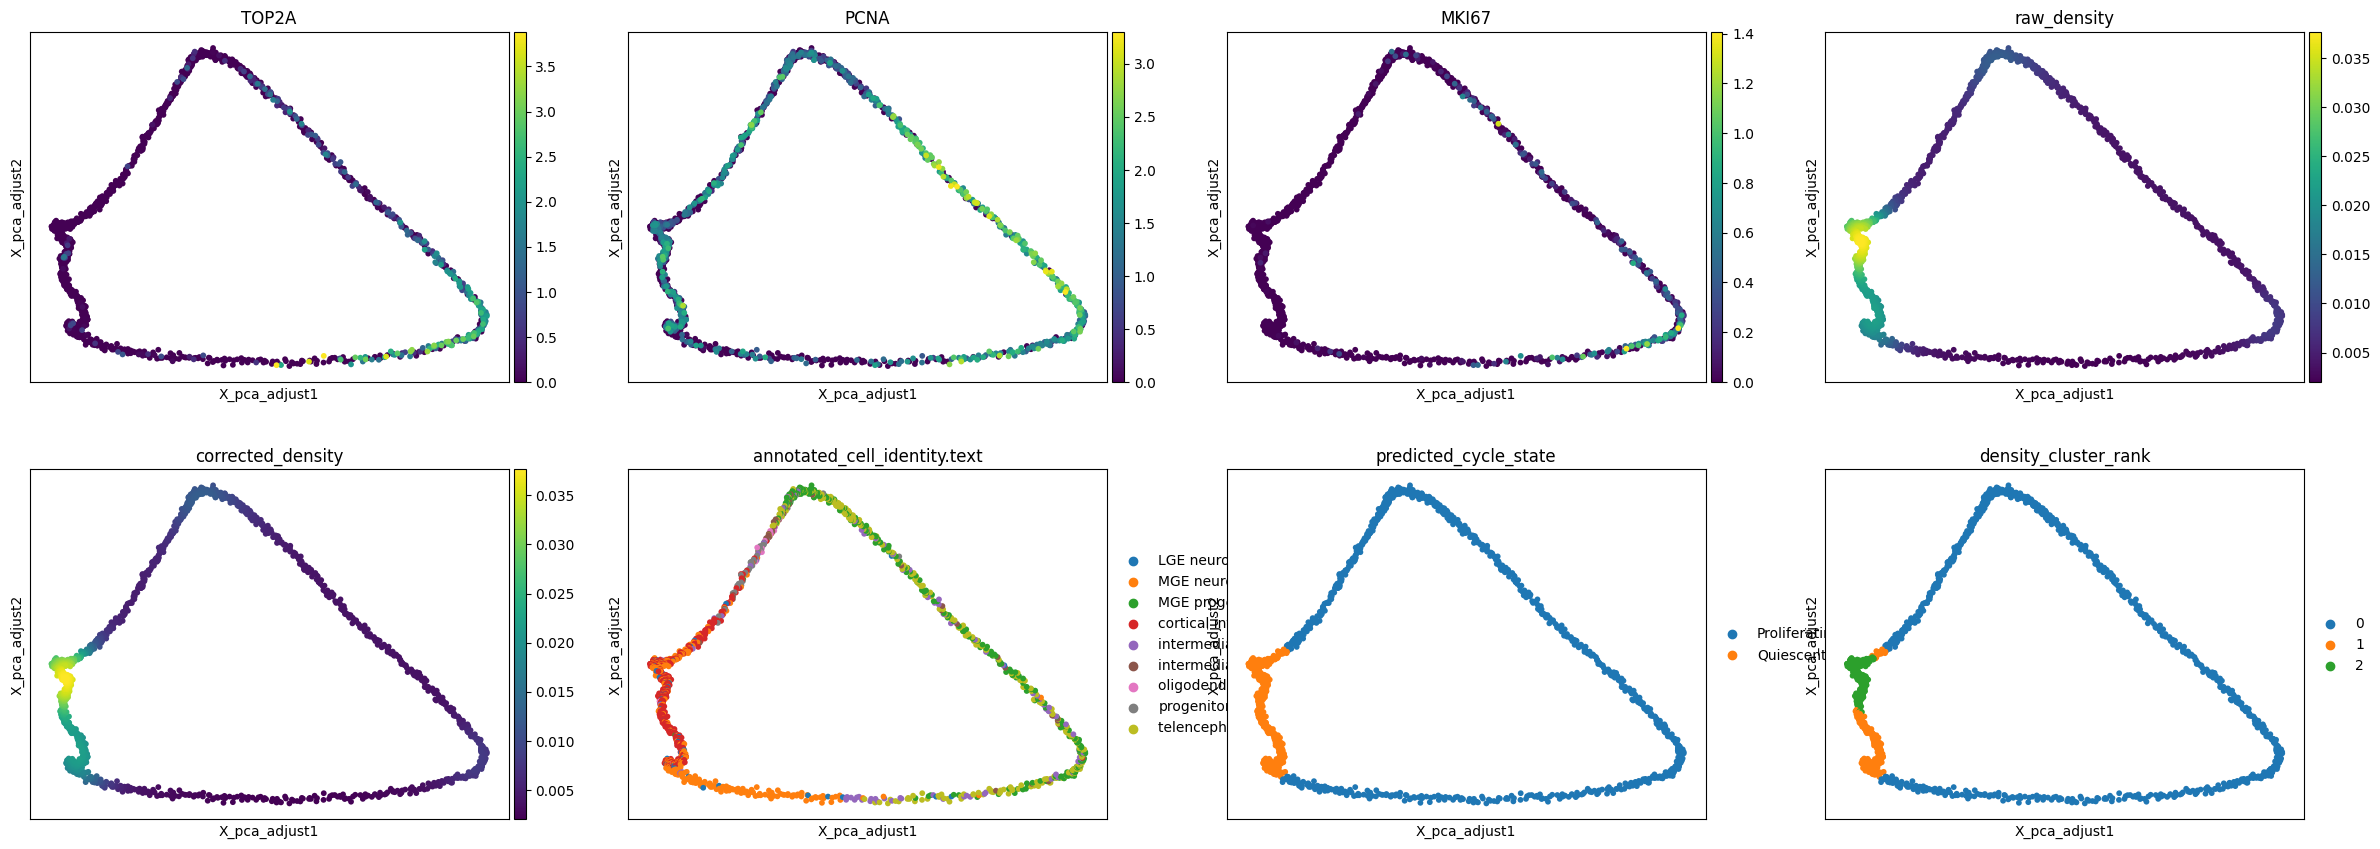

/root/anaconda3/envs/HT2VEC/envs/CycleAtlas/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/root/anaconda3/envs/HT2VEC/envs/CycleAtlas/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/root/anaconda3/envs/HT2VEC/envs/CycleAtlas/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


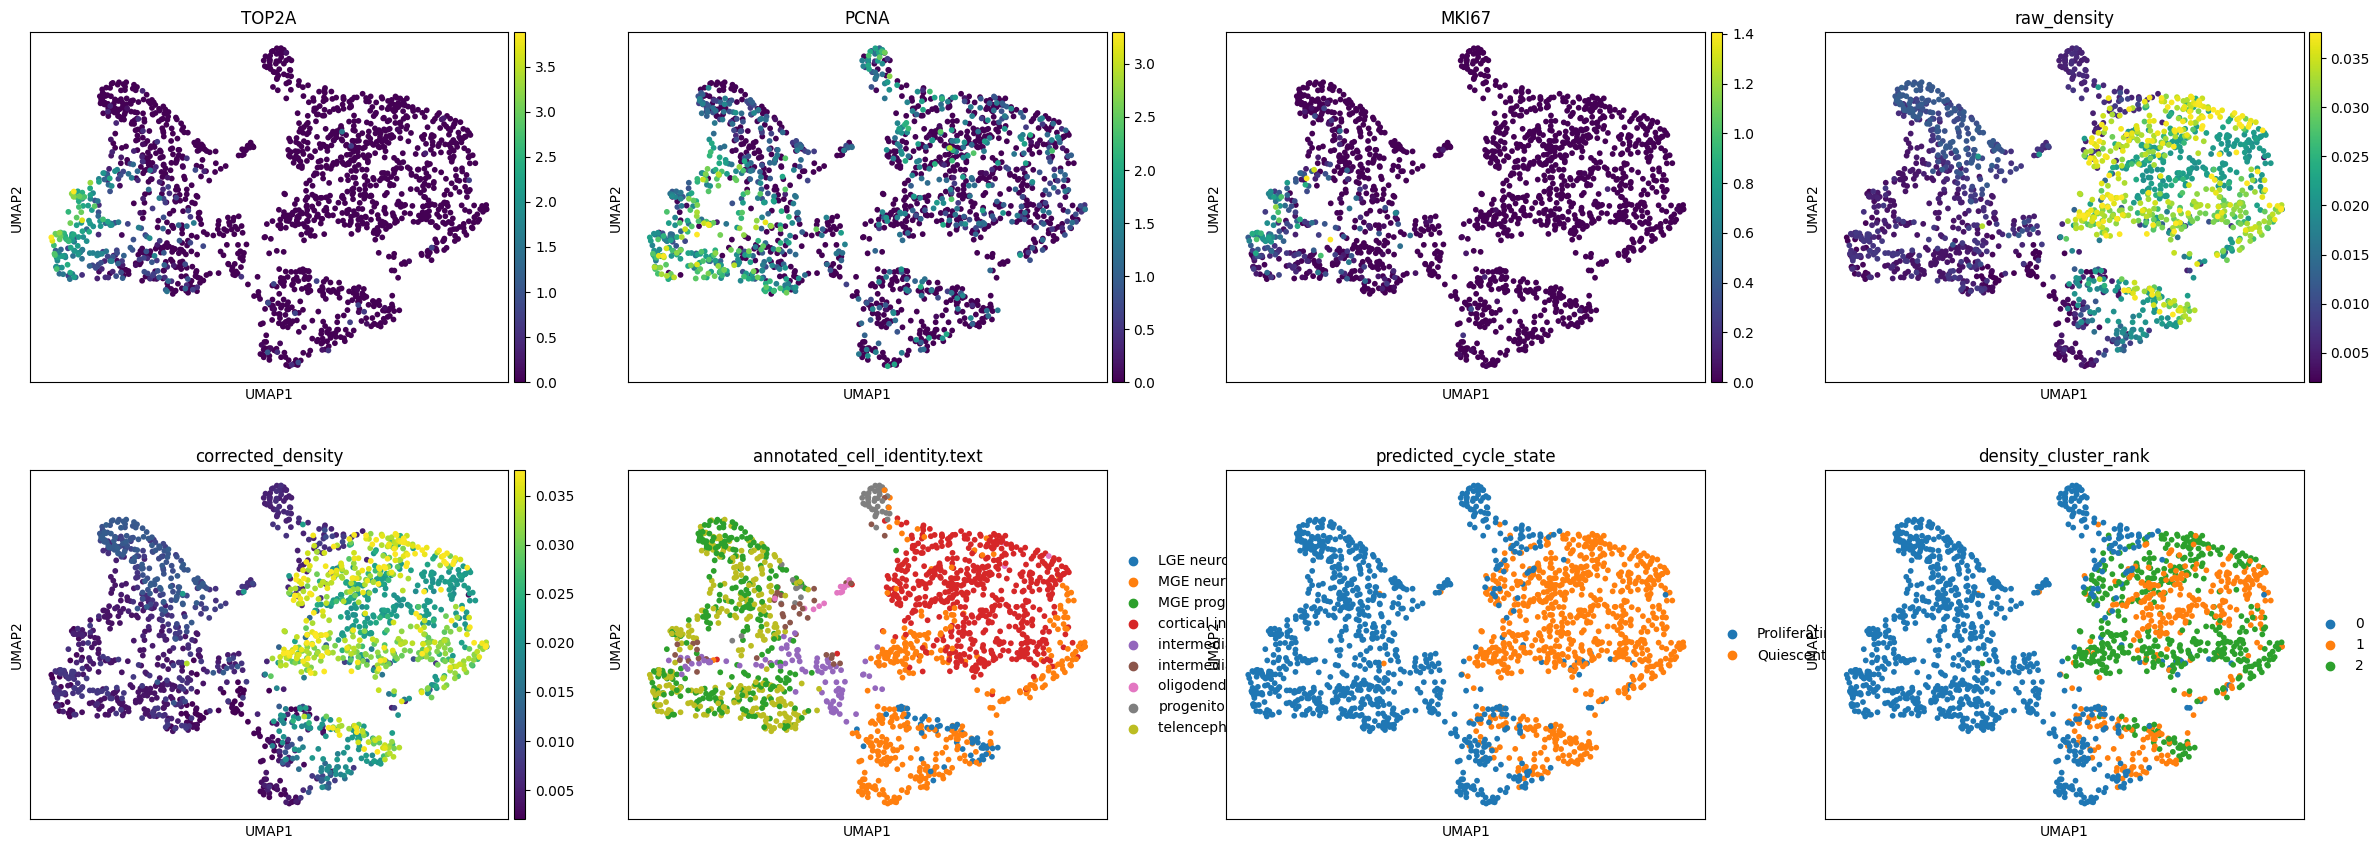

In [7]:
harmo_adata1.obs['density_cluster_rank'] = harmo_adata1.obs.density_cluster_rank.astype(str)  
sc.pl.embedding(harmo_adata1, basis='X_pca_adjust', color=['TOP2A', 'PCNA', 'MKI67', 'raw_density', 'corrected_density', 'annotated_cell_identity.text', 'predicted_cycle_state', 'density_cluster_rank'])
sc.pl.umap(harmo_adata1, color=['TOP2A', 'PCNA', 'MKI67', 'raw_density', 'corrected_density', 'annotated_cell_identity.text', 'predicted_cycle_state', 'density_cluster_rank'])


## 7. Baseline Comparison: Traditional Cell Cycle Scoring

Before diving deeper into the HarmoCycle results, let's examine the preliminary results obtained using **traditional cell cycle gene sets**. Standard analysis pipelines often use a predefined list of S-phase and G2M-phase marker genes to score cells and assign them to a specific phase (G1, S, or G2/M).

By performing this scoring first, we can establish a baseline and better appreciate how HarmoCycle refines the identification of cycling versus quiescent states.

/root/anaconda3/envs/HT2VEC/envs/CycleAtlas/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/root/anaconda3/envs/HT2VEC/envs/CycleAtlas/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/root/anaconda3/envs/HT2VEC/envs/CycleAtlas/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/tmp/ipykernel_9659/2878027074.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()           # Auto-adjust subplot parameters to give room for labels


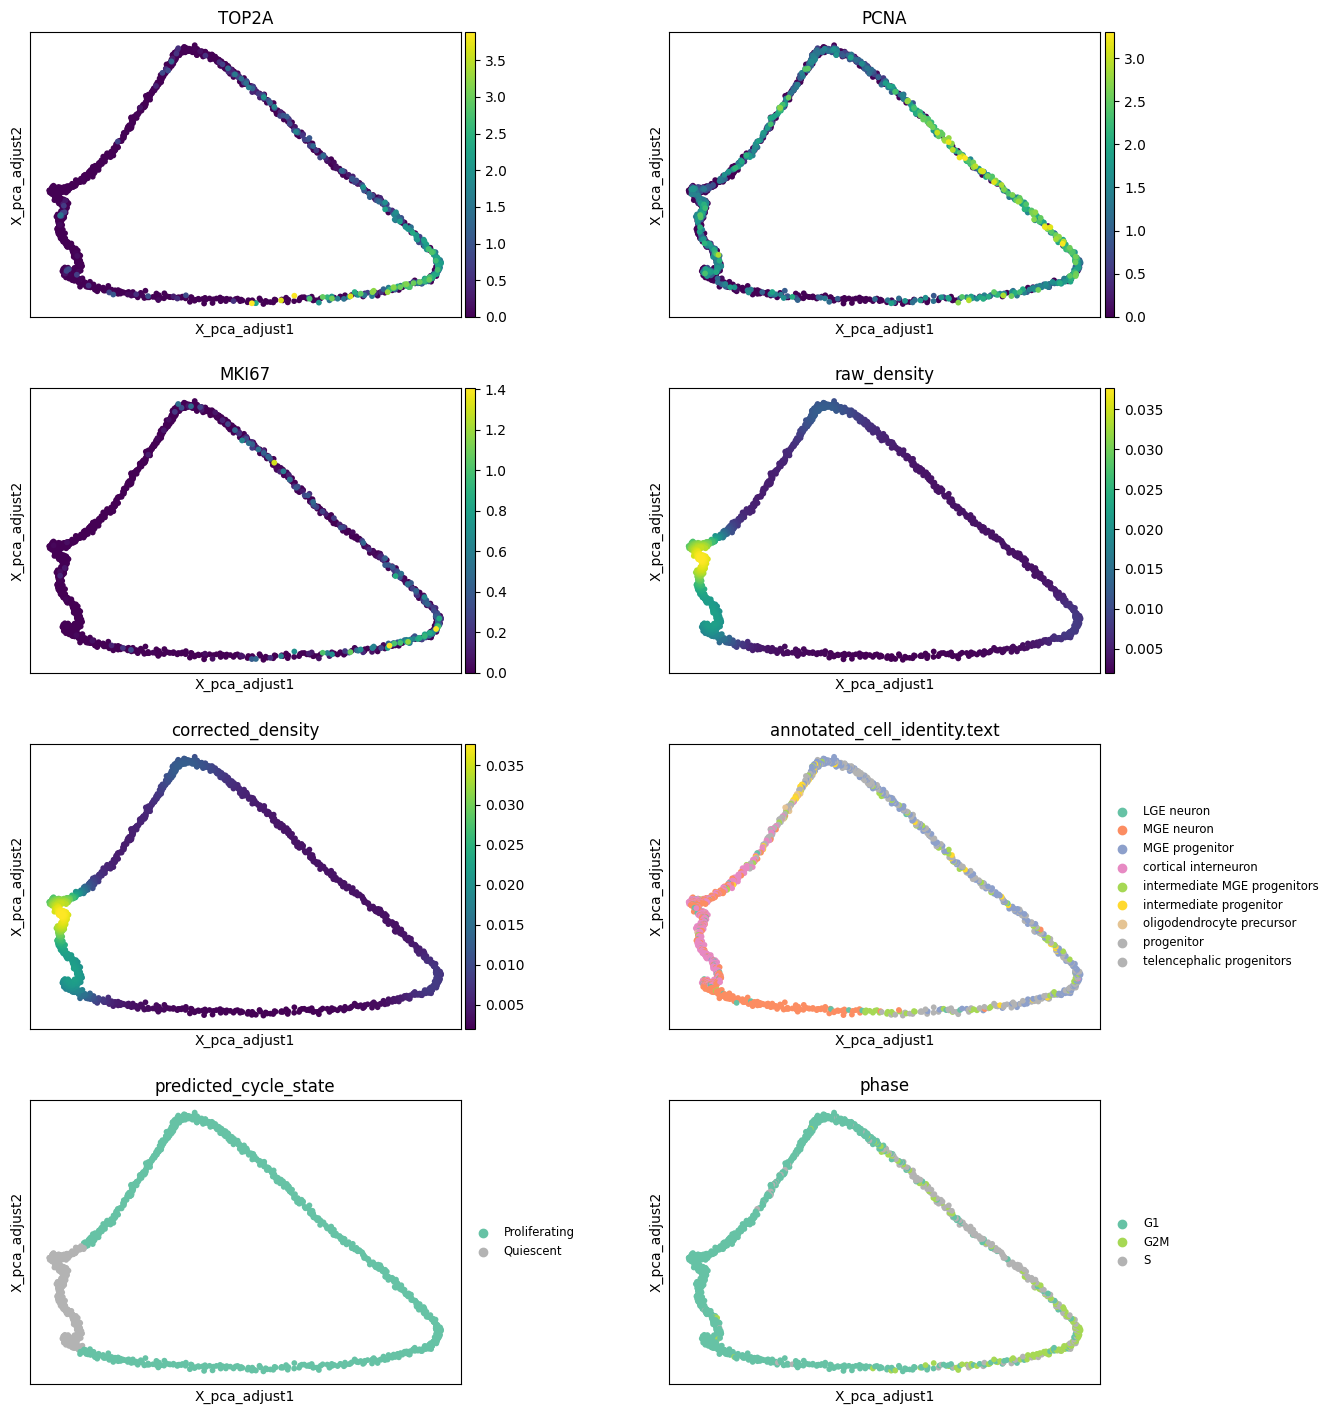

/root/anaconda3/envs/HT2VEC/envs/CycleAtlas/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/root/anaconda3/envs/HT2VEC/envs/CycleAtlas/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/root/anaconda3/envs/HT2VEC/envs/CycleAtlas/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/tmp/ipykernel_9659/2878027074.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()           # Auto-adjust subplot parameters to give room for labels


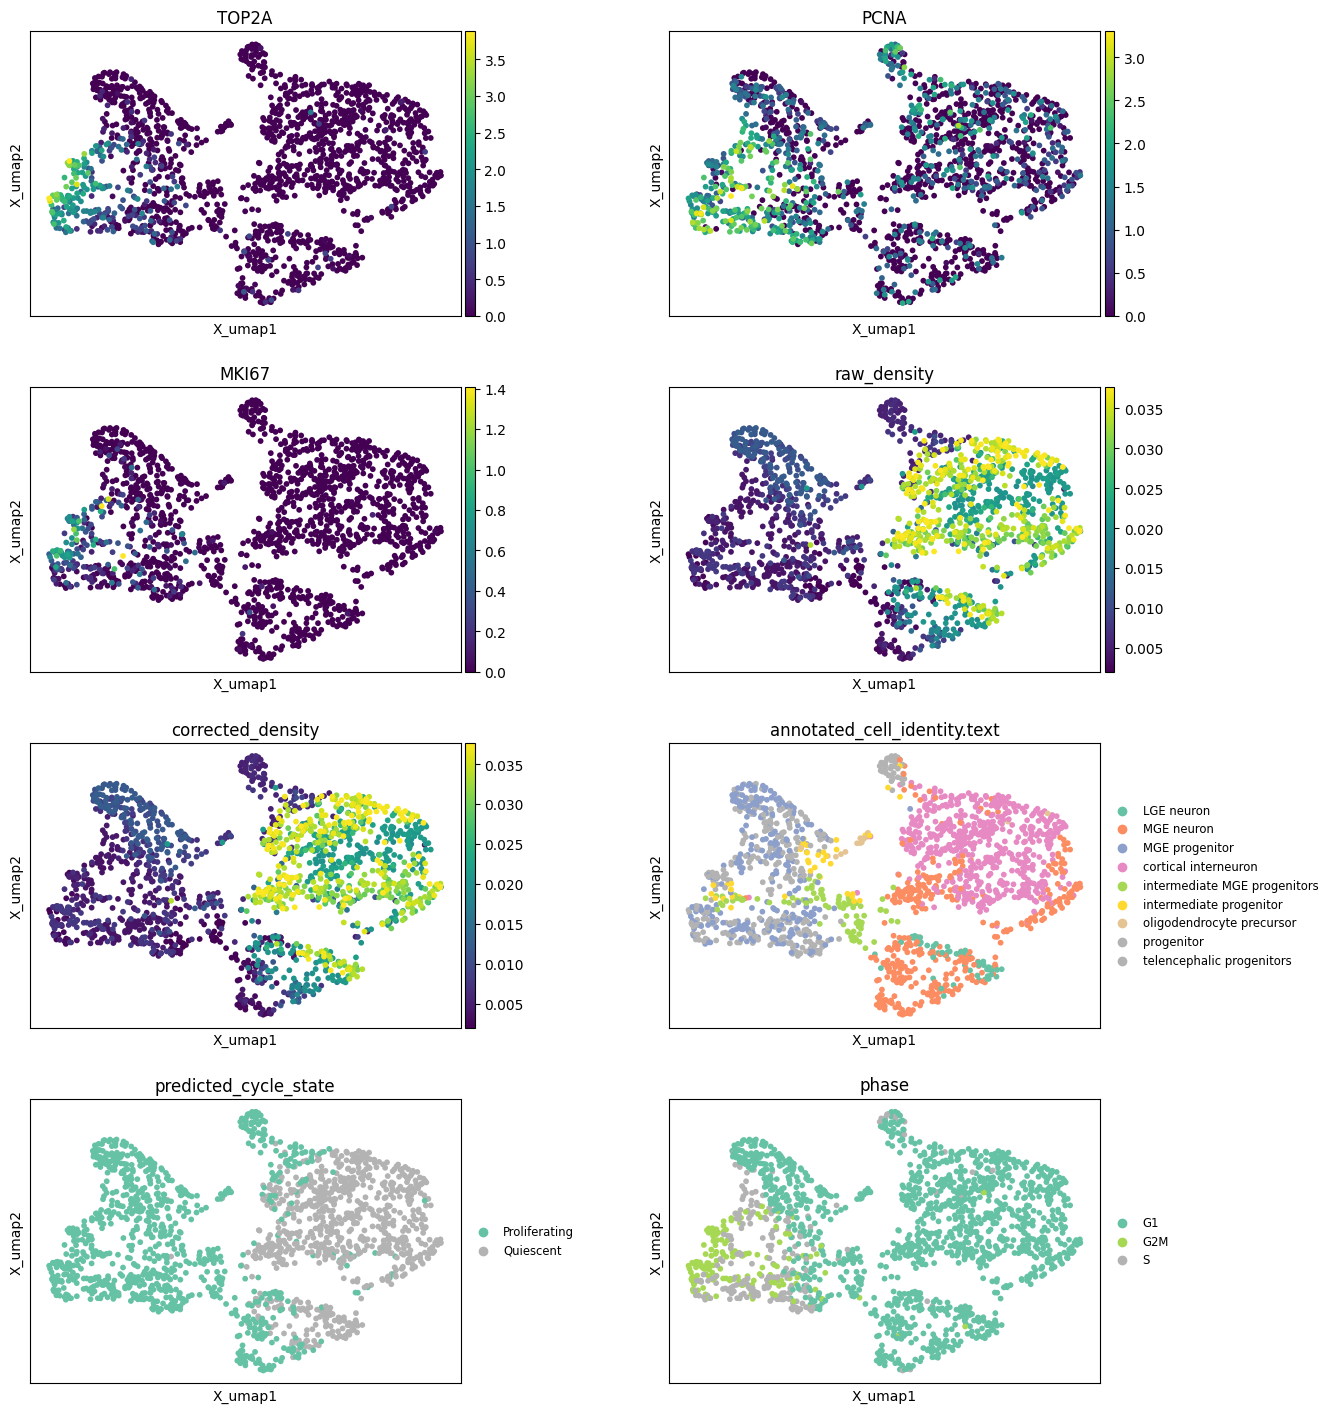

In [22]:
s_genes = ["MCM5", "PCNA", "TYMS", "FEN1", "MCM2", "MCM4", "RRM1", "UNG", "GINS2", "MCM6", "CDCA7", "DTL", "VMP1", "UHRF1", "MLF1IP", "HELLS", "RFC2", "RPA2", "NASP", "RAD51AP1", "GMNN", "WDR76", "SLBP", "CCNE2", "UBR7", "POLD3", "MSH2", "ATAD2", "RAD51", "RRM2", "CDC45", "CDC6", "EXO1", "TIPIN", "DSCC1", "BLM", "CASP8AP2", "USP1", "CLSPN", "POLA1", "CHAF1B", "BRIP1", "E2F8"]
g2m_genes = ["HMGB2", "CDK1", "NUSAP1", "UBE2C", "BIRC5", "TPX2", "TOP2A", "NDC80", "CKS2", "NUF2", "CKS1B", "MKI67", "TMPO", "CENPF", "TACC3", "FAM64A", "SMC4", "CCNB2", "CKAP2L", "CKAP2", "AURKB", "BUB1", "KIF11", "ANP32E", "TUBB4B", "GTSE1", "KIF20B", "HJURP", "CDCA3", "HN1", "CDC20", "TTK", "CDC25C", "KIF2C", "RANGAP1", "NCAPD2", "DLGAP5", "CDCA2", "CDCA8", "ECT2", "KIF23", "HMMR", "AURKA", "PSRC1", "ANLN", "LBR", "CKAP5", "CENPE", "CTCF", "NEK2", "G2E3", "GAS2L3", "CBX5", "CENPA"]

s_genes_inter = [g for g in s_genes if g in harmo_adata1.var_names]
g2m_genes_inter = [g for g in g2m_genes if g in harmo_adata1.var_names]

sc.tl.score_genes_cell_cycle(harmo_adata1, s_genes=s_genes_inter, g2m_genes=g2m_genes_inter)

harmo_adata1.obs['density_cluster_rank'] = harmo_adata1.obs.density_cluster_rank.astype(str)  

import scanpy as sc
import matplotlib.pyplot as plt

sc.pl.embedding(
    harmo_adata1, 
    basis='X_pca_adjust',      # Explicitly specify the coordinates used in your images
    color=['TOP2A', 'PCNA', 'MKI67', 'raw_density', 'corrected_density', 'annotated_cell_identity.text', 'predicted_cycle_state', 'phase'],
    
    # --- Layout & Spacing ---
    ncols=2,                 # Arrange in 2 columns (2x2 grid) to prevent the figure from being too wide
    wspace=0.35,             # Increase horizontal spacing between subplots to avoid legend overlapping
    hspace=0.25,             # Set vertical spacing between rows

    # --- Legend Control ---
    legend_fontsize='small', # Shrink legend text to fit more categories
    legend_loc='right margin', # Ensure legends stay on the right side of each subplot
    # legend_loc='on data',  # Tip: Uncomment this to put labels directly on the clusters
    
    show=False               # Don't show yet, allow for further matplotlib adjustments
)

fig = plt.gcf()
fig.set_size_inches(14, 16)  # Adjust width and height as needed
plt.tight_layout()           # Auto-adjust subplot parameters to give room for labels
plt.show()

sc.pl.embedding(
    harmo_adata1, 
    basis='X_umap',      # Explicitly specify the coordinates used in your images
    color=['TOP2A', 'PCNA', 'MKI67', 'raw_density', 'corrected_density', 'annotated_cell_identity.text', 'predicted_cycle_state', 'phase'],
    
    # --- Layout & Spacing ---
    ncols=2,                 # Arrange in 2 columns (2x2 grid) to prevent the figure from being too wide
    wspace=0.35,             # Increase horizontal spacing between subplots to avoid legend overlapping
    hspace=0.25,             # Set vertical spacing between rows

    # --- Legend Control ---
    legend_fontsize='small', # Shrink legend text to fit more categories
    legend_loc='right margin', # Ensure legends stay on the right side of each subplot
    # legend_loc='on data',  # Tip: Uncomment this to put labels directly on the clusters
    
    show=False               # Don't show yet, allow for further matplotlib adjustments
)

# Use matplotlib to fine-tune the overall canvas size
fig = plt.gcf()
fig.set_size_inches(14, 16)  # Adjust width and height as needed
plt.tight_layout()           # Auto-adjust subplot parameters to give room for labels
plt.show()

As we can observe, traditional scoring strategies lead to certain progenitor cell types being annotated as G1, which is biologically implausible.

## 8. Subset Cycling Cells
Next, we will extract proliferating cells for downstream analysis. We will utilize the predicted_cycle_state column to filter for cells in the active G1, S, and G2M phases, which are traditionally recognized as the actively dividing stages of the cell cycle.

/root/anaconda3/envs/HT2VEC/envs/CycleAtlas/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/root/anaconda3/envs/HT2VEC/envs/CycleAtlas/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


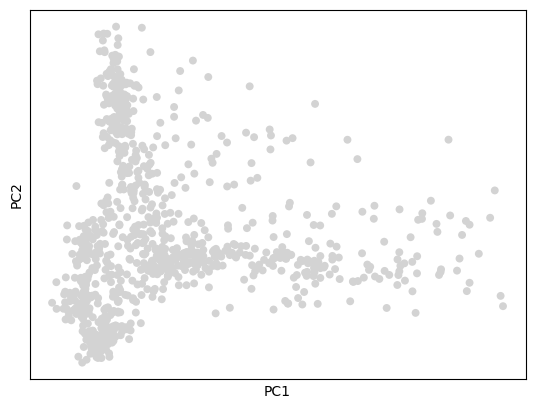

/root/anaconda3/envs/HT2VEC/envs/CycleAtlas/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/root/anaconda3/envs/HT2VEC/envs/CycleAtlas/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


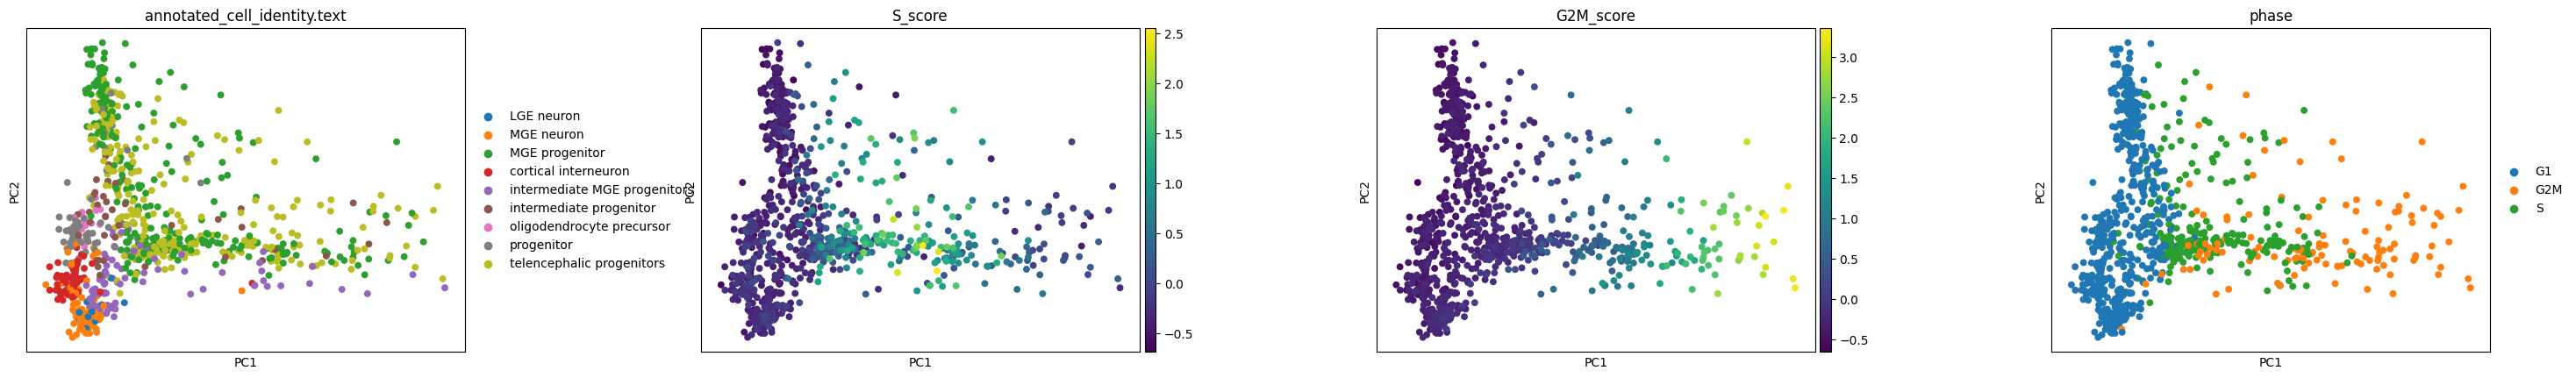

In [23]:
import scanpy as sc
import pandas as pd
import numpy as np

# Load the dataset
harmo_adata1 = sc.read_h5ad('/root/Cycle/Github/Tutorial/human_close-2017/GMM_n3_top1_bw1.0.h5ad')

# Subset the data into proliferating (cycling) and quiescent (non-cycling) populations
cycling_adata1 = harmo_adata1[harmo_adata1.obs['predicted_cycle_state'] == 'Proliferating']
non_cycling_adata1 = harmo_adata1[harmo_adata1.obs['predicted_cycle_state'] == 'Quiescent']

# 1. Normalization: Scale the total counts for each cell to 10,000 (or the sample median)
sc.pp.normalize_total(cycling_adata1, target_sum=1e4)

# 2. Log Transformation: Calculate log(1 + x)
sc.pp.log1p(cycling_adata1)

# Store a copy of the non-scaled data in .raw for future Differential Expression Analysis (DEGs)
cycling_adata1.raw = cycling_adata1

# 3. Identify Highly Variable Genes (HVGs)
# Defaults to the 'seurat' flavor, which is appropriate for log-transformed data.
sc.pp.highly_variable_genes(cycling_adata1, flavor='seurat', n_top_genes=1000)

# 4. Scaling: Center and scale the data
sc.pp.scale(cycling_adata1, max_value=10)

# 5. Run Principal Component Analysis (PCA)
# By default, PCA is performed using only the previously identified highly variable genes.
sc.tl.pca(cycling_adata1, svd_solver='arpack')

# 6. Visualize PCA results
sc.pl.pca(cycling_adata1)
# Calculate intersection to ensure genes exist in the dataset
s_genes_inter = [x for x in s_genes if x in cycling_adata1.var_names]
g2m_genes_inter = [x for x in g2m_genes if x in cycling_adata1.var_names]

sc.tl.score_genes_cell_cycle(cycling_adata1, s_genes=s_genes_inter, g2m_genes=g2m_genes_inter)

# Plot PCA results colored by Identity, Phase Scores, and assigned Phase
sc.pl.pca(
    cycling_adata1, 
    color=['annotated_cell_identity.text', 'S_score', 'G2M_score', 'phase'], 
    wspace=0.4
)

Next, let us employ the HarmoCycle annotation strategy to re-evaluate the cell cycle states.

We observed that telencephalic and MGE progenitors do not show distinct separation in the PC space; therefore, we are merging these two cell types.

In [24]:
# We observed that telencephalic and MGE progenitors show minimal separation 
# in the PC space; therefore, we merge these two cell types into a single category.
harmo_adata1.obs['celltype'] = harmo_adata1.obs['annotated_cell_identity.text'].replace(
    {"telencephalic progenitors": "Telencephalic/MGE progenitors",
     "MGE progenitor": "Telencephalic/MGE progenitors"}
)
harmo_adata1.write_h5ad('/root/Cycle/Github/Tutorial/human_close-2017/GMM_n3_top1_bw1.0_temp.h5ad')

## 9. Cell Cycle Phase Annotation

In [23]:
!python /root/Cycle/Github/HarmoCycle/HarmoCycle_Stage_v3.py \
  --input_h5ad "/root/Cycle/Github/Tutorial/human_close-2017/GMM_n3_top1_bw1.0_temp.h5ad" \
  --output_path "/root/Cycle/Github/Tutorial/human_close-2017/WHOLE_HarmoCycle_Annotated.h5ad" \
  --code_dir "/root/Cycle/Github/HarmoCycle" \
  --ref_data_dir "/root/Cycle/Github/Dataset" \
  --ref_datasets hESC.h5ad hU2OS.h5ad \
  --cell_type_key "celltype" \
  --density_key "corrected_density" \
  --hc_epochs 2000 \
  --hc_batch_size 1024 \
  --hc_top_genes 20000 \
  --periodic_top_k 10 \
  --anchor_threshold 0.2 \
  --max_gmm_comp 10 \
  --dann_epochs 100 \
  --dann_lr 0.001 \
  --device "cuda:1"


[INFO] Running with device: cuda:1
[INFO] HarmoCycle modules loaded from /root/Cycle/Github/HarmoCycle.
[INFO] Loading input adata from /root/Cycle/Github/Tutorial/human_close-2017/GMM_n3_top1_bw1.0_temp.h5ad...
[INFO] Status counts:
Cycling      929
Quiescent    803
Name: cell_cycle_status, dtype: int64
[INFO] Loading reference datasets from /root/Cycle/Github/Dataset...
       Selected references: ['hESC.h5ad', 'hU2OS.h5ad']
  [SUCCESS] Loaded hESC.h5ad
  [SUCCESS] Loaded hU2OS.h5ad
--- Processing dataset: ref_dataset0 ---
Found 673 marker genes for phase 'G1'.
Found 1000 marker genes for phase 'S'.
Found 741 marker genes for phase 'G2M'.
--- Processing dataset: ref_dataset1 ---
Found 1000 marker genes for phase 'G1'.
Found 1000 marker genes for phase 'S'.
Found 1000 marker genes for phase 'G2M'.

--- Processing complete. ---
[INFO] Processing 8 cell types...
  0%|                                                     | 0/8 [00:00<?, ?it/s]Epoch 1/2000, Loss: 0.1605
Epoch 50/2000, Loss

Let's examine the results.

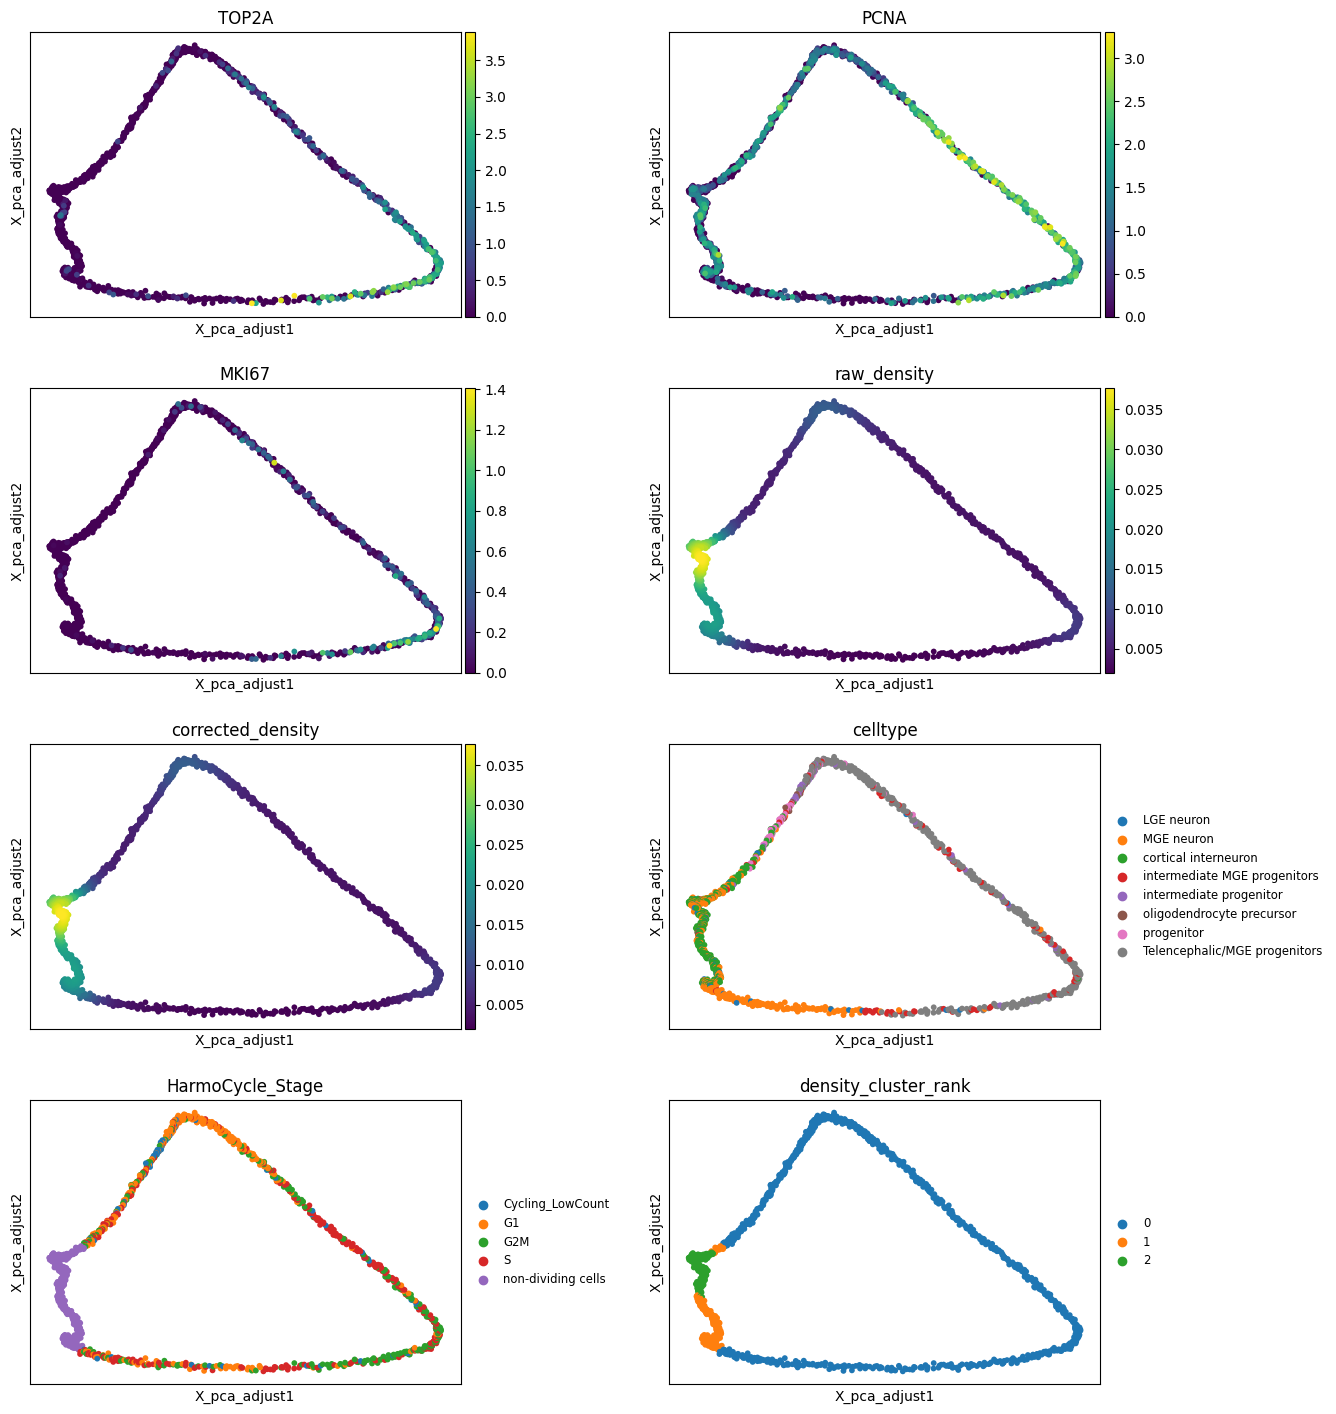

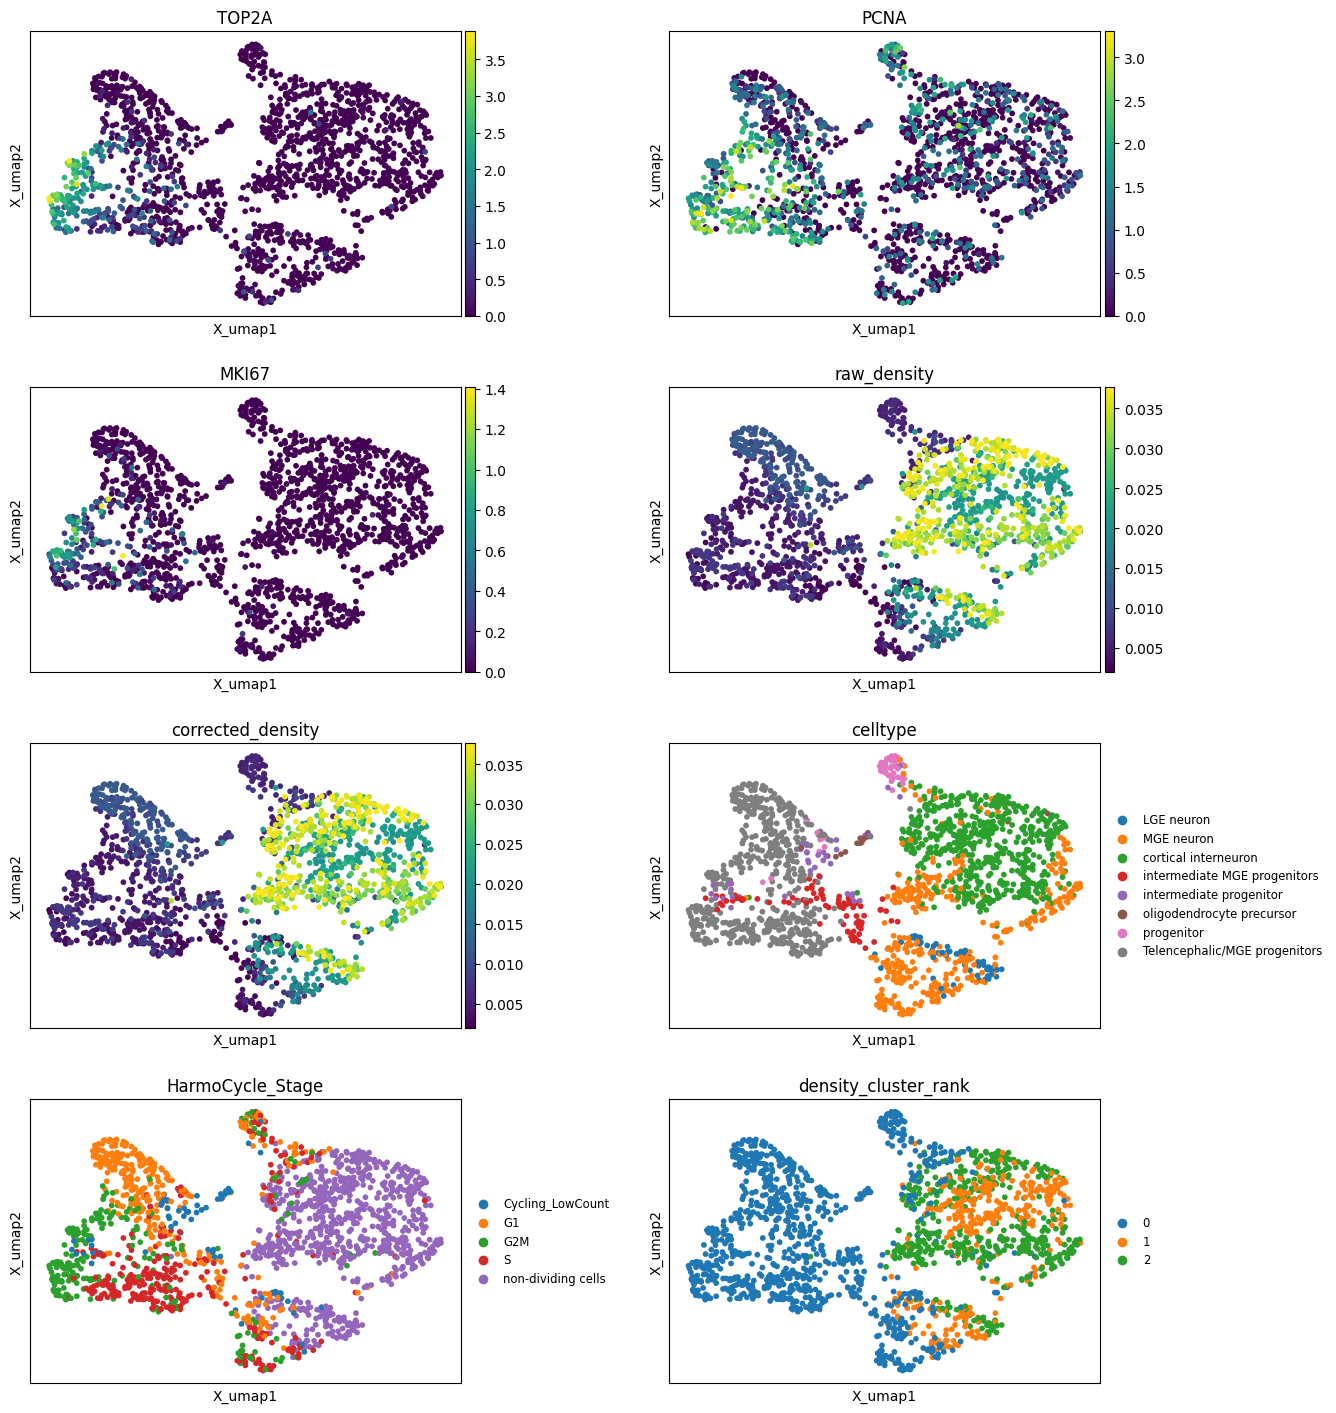

In [24]:
import matplotlib.pyplot as plt
import scanpy as sc
stage_adata1 = sc.read_h5ad('/root/Cycle/Github/Tutorial/human_close-2017/WHOLE_HarmoCycle_Annotated.h5ad')
stage_adata1
sc.pp.normalize_total(stage_adata1, target_sum=1e4)
sc.pp.log1p(stage_adata1)
stage_adata1.obs['density_cluster_rank'] = stage_adata1.obs.density_cluster_rank.astype(str)  


sc.pl.embedding(
    stage_adata1, 
    basis='X_pca_adjust',      # Explicitly specify the coordinates used in your images
    color=['TOP2A', 'PCNA', 'MKI67', 'raw_density', 'corrected_density', 'celltype', 'HarmoCycle_Stage', 'density_cluster_rank'],
    
    # --- Layout & Spacing ---
    ncols=2,                 # Arrange in 2 columns (2x2 grid) to prevent the figure from being too wide
    wspace=0.35,             # Increase horizontal spacing between subplots to avoid legend overlapping
    hspace=0.25,             # Set vertical spacing between rows

    # --- Legend Control ---
    legend_fontsize='small', # Shrink legend text to fit more categories
    legend_loc='right margin', # Ensure legends stay on the right side of each subplot
    # legend_loc='on data',  # Tip: Uncomment this to put labels directly on the clusters
    
    show=False               # Don't show yet, allow for further matplotlib adjustments
)

# Use matplotlib to fine-tune the overall canvas size
fig = plt.gcf()
fig.set_size_inches(14, 16)  # Adjust width and height as needed
plt.tight_layout()           # Auto-adjust subplot parameters to give room for labels
plt.show()

sc.pl.embedding(
    stage_adata1, 
    basis='X_umap',      # Explicitly specify the coordinates used in your images
    color=['TOP2A', 'PCNA', 'MKI67', 'raw_density', 'corrected_density', 'celltype', 'HarmoCycle_Stage', 'density_cluster_rank'],
    
    # --- Layout & Spacing ---
    ncols=2,                 # Arrange in 2 columns (2x2 grid) to prevent the figure from being too wide
    wspace=0.35,             # Increase horizontal spacing between subplots to avoid legend overlapping
    hspace=0.25,             # Set vertical spacing between rows

    # --- Legend Control ---
    legend_fontsize='small', # Shrink legend text to fit more categories
    legend_loc='right margin', # Ensure legends stay on the right side of each subplot
    # legend_loc='on data',  # Tip: Uncomment this to put labels directly on the clusters
    
    show=False               # Don't show yet, allow for further matplotlib adjustments
)

# Use matplotlib to fine-tune the overall canvas size
fig = plt.gcf()
fig.set_size_inches(14, 16)  # Adjust width and height as needed
plt.tight_layout()           # Auto-adjust subplot parameters to give room for labels
plt.show()

In [25]:
s_genes = ["MCM5", "PCNA", "TYMS", "FEN1", "MCM2", "MCM4", "RRM1", "UNG", "GINS2", "MCM6", "CDCA7", "DTL", "VMP1", "UHRF1", "MLF1IP", "HELLS", "RFC2", "RPA2", "NASP", "RAD51AP1", "GMNN", "WDR76", "SLBP", "CCNE2", "UBR7", "POLD3", "MSH2", "ATAD2", "RAD51", "RRM2", "CDC45", "CDC6", "EXO1", "TIPIN", "DSCC1", "BLM", "CASP8AP2", "USP1", "CLSPN", "POLA1", "CHAF1B", "BRIP1", "E2F8"]
g2m_genes = ["HMGB2", "CDK1", "NUSAP1", "UBE2C", "BIRC5", "TPX2", "TOP2A", "NDC80", "CKS2", "NUF2", "CKS1B", "MKI67", "TMPO", "CENPF", "TACC3", "FAM64A", "SMC4", "CCNB2", "CKAP2L", "CKAP2", "AURKB", "BUB1", "KIF11", "ANP32E", "TUBB4B", "GTSE1", "KIF20B", "HJURP", "CDCA3", "HN1", "CDC20", "TTK", "CDC25C", "KIF2C", "RANGAP1", "NCAPD2", "DLGAP5", "CDCA2", "CDCA8", "ECT2", "KIF23", "HMMR", "AURKA", "PSRC1", "ANLN", "LBR", "CKAP5", "CENPE", "CTCF", "NEK2", "G2E3", "GAS2L3", "CBX5", "CENPA"]

harmo_adata1 = sc.read_h5ad('/root/Cycle/Github/Tutorial/human_close-2017/GMM_n3_top1_bw1.0_temp.h5ad')
cycling_adata1 = harmo_adata1[harmo_adata1.obs['predicted_cycle_state'] == 'Proliferating']
cycling_adata1 = harmo_adata1[harmo_adata1.obs['celltype'].isin(['MGE progenitor', 'telencephalic progenitors','Telencephalic/MGE progenitors'])]
sc.pp.normalize_total(cycling_adata1, target_sum=1e4)
sc.pp.log1p(cycling_adata1)
s_genes_inter = [g for g in s_genes if g in cycling_adata1.var_names]
g2m_genes_inter = [g for g in g2m_genes if g in cycling_adata1.var_names]

# 计算细胞周期评分
sc.tl.score_genes_cell_cycle(cycling_adata1, s_genes=s_genes_inter, g2m_genes=g2m_genes_inter)

In [26]:
import os
import sys
import numpy as np
import scanpy as sc

# Set working directory to /root/Cycle/Github
os.chdir("/root/Cycle/Github")

# Print the current working directory
print("Current working directory:", os.getcwd())

# Add HarmoCycle module path
sys.path.append("./HarmoCycle/")

# Import functions from HarmoCycle and Utils
from HarmoCycle import *
from Utils import set_seed, calculate_gene_oscillation_properties_v2

# Set random seed for reproducibility
set_seed(79710)

# Load dataset
adata1 = cycling_adata1.copy()

# Normalize total counts per cell to 1e4
sc.pp.normalize_total(adata1, target_sum=1e4)

# Log-transform the data
sc.pp.log1p(adata1)

# Randomly shuffle cells
adata1 = adata1[np.random.permutation(adata1.n_obs), :]

# Run HarmoCycle pipeline
_, _, adata_res1 = run_pipeline(
    adata1,
    epochs=2000,
    batch_size=1024,
    top_n_genes=20000,
    device='cuda:1'
)

# Sort cells by pseudo-angle
adata1 = adata1[adata1.obs['pseudo_angle'].sort_values().index, :]

# Construct periodic matrix using top_k genes
periodic_adata = get_periodic_matrix(
    adata1.copy(),
    top_k=10,
    use_highly_variable=True
)

# Calculate PCA-based angle adjustment
adjust_adata1 = calculate_pca_angle(
    periodic_adata,
    use_rep='X',
    pca_key_added='X_pca_adjust',
    angle_key_added='pca_adjust_angle',
    plot=False
)

# Sort cells by adjusted PCA angle
adjust_adata1 = adjust_adata1[adjust_adata1.obs.sort_values(by='pca_adjust_angle').index, :]


Current working directory: /root/Cycle/Github


Epoch 1/2000, Loss: 0.3885
Epoch 50/2000, Loss: 0.2073
Epoch 100/2000, Loss: 0.2046
Epoch 150/2000, Loss: 0.2024
Epoch 200/2000, Loss: 0.2004
Epoch 250/2000, Loss: 0.1985
Epoch 300/2000, Loss: 0.1968
Epoch 350/2000, Loss: 0.1954
Epoch 400/2000, Loss: 0.1941
Epoch 450/2000, Loss: 0.1931
Epoch 500/2000, Loss: 0.1919
Epoch 550/2000, Loss: 0.1910
Epoch 600/2000, Loss: 0.1901
Epoch 650/2000, Loss: 0.1893
Epoch 700/2000, Loss: 0.1885
Epoch 750/2000, Loss: 0.1879
Epoch 800/2000, Loss: 0.1871
Epoch 850/2000, Loss: 0.1865
Epoch 900/2000, Loss: 0.1859
Epoch 950/2000, Loss: 0.1853
Epoch 1000/2000, Loss: 0.1846
Epoch 1050/2000, Loss: 0.1843
Epoch 1100/2000, Loss: 0.1835
Epoch 1150/2000, Loss: 0.1835
Epoch 1200/2000, Loss: 0.1826
Epoch 1250/2000, Loss: 0.1821
Epoch 1300/2000, Loss: 0.1817
Epoch 1350/2000, Loss: 0.1813
Epoch 1400/2000, Loss: 0.1808
Epoch 1450/2000, Loss: 0.1805
Epoch 1500/2000, Loss: 0.1800
Epoch 1550/2000, Loss: 0.1797
Epoch 1600/2000, Loss: 0.1792
Epoch 1650/2000, Loss: 0.1792
Epo

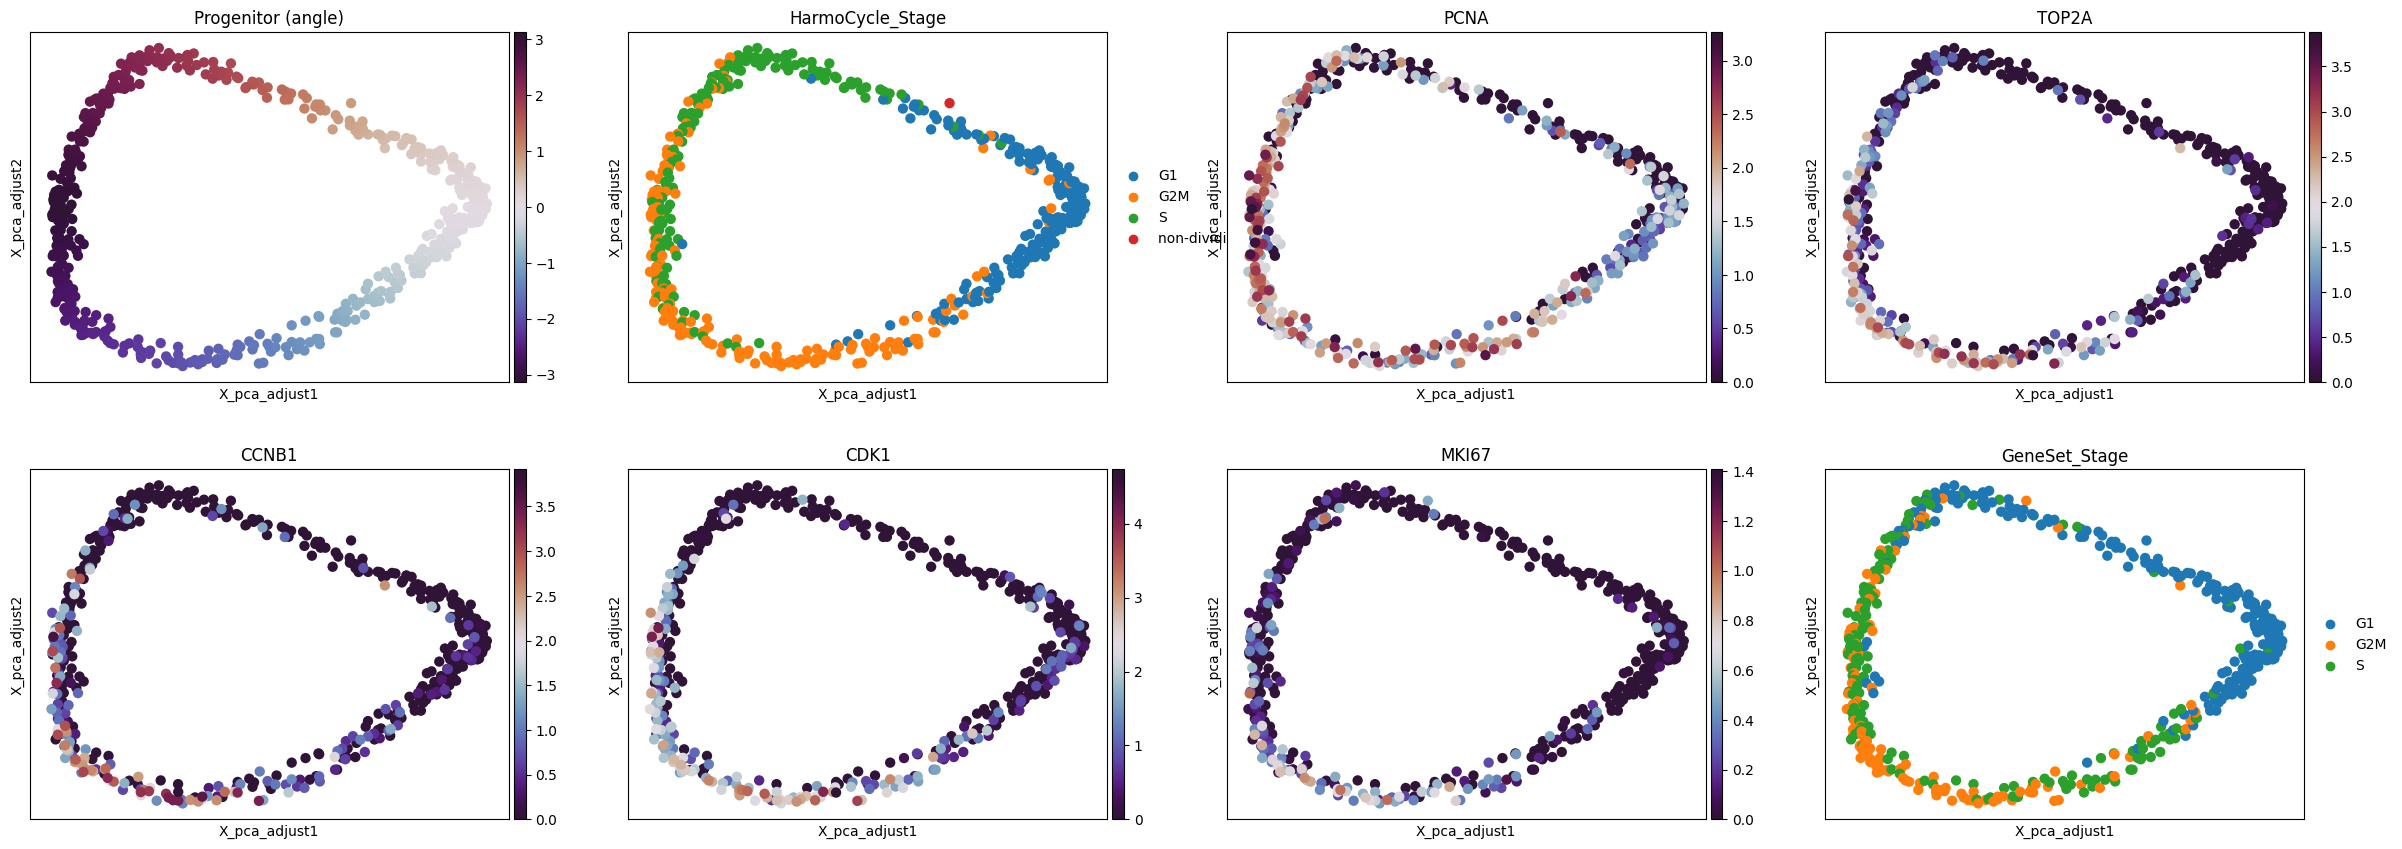

In [27]:
adjust_adata1.obs['GeneSet_Stage'] = cycling_adata1[adjust_adata1.obs_names, ].obs['phase'].values
adjust_adata1.obs['HarmoCycle_Stage'] = stage_adata1[adjust_adata1.obs_names, ].obs['HarmoCycle_Stage'].values
cycling_adata1 = cycling_adata1[adjust_adata1.obs_names, ]
adjust_adata1.X = cycling_adata1.X

sc.pl.embedding(
    adjust_adata1,
    basis='X_pca_adjust',
    color=[
        'pca_adjust_angle', 
        'HarmoCycle_Stage', 
        'PCNA', 'TOP2A',
        'CCNB1', 'CDK1', 'MKI67', 'GeneSet_Stage'
    ],
    title='Progenitor (angle)',
    cmap='twilight_shifted',
    show=True,
)


## 10. Identification of Periodically Expressed Genes


In [30]:
adjust_adata1 = calculate_gene_oscillation_properties_v2(adjust_adata1)

View the calculated frequency-domain features


- **`dominant_frequency_bin`**  
  Represents the frequency "bin" (interval) where the spectral energy is maximized.

- **`dominant_amplitude`**  
  The amplitude (intensity) of the dominant frequency component, reflecting the energy or strength of the signal at that specific frequency.

- **`dominant_phase_rad`**  
  The phase of the dominant frequency component expressed in radians. Phase describes the temporal offset or "shift" of the signal.

- **`dominant_phase_deg`**  
  The same phase value expressed in degrees for easier interpretation.  
  Conversion: $\text{phase\_deg} = \text{phase\_rad} \times \frac{180}{\pi}$

- **`dominant_phase_norm`**  
  The normalized phase value, typically mapped to the range $[0, 1]$. This facilitates comparison between genes and can be used as a standardized feature for downstream modeling.

In [31]:
freq_df = adjust_adata1.var.sort_values(
    by="dominant_amplitude", 
    ascending=False
)

print(freq_df.head(5))


         highly_variable     means  dispersions  dispersions_norm  \
gene                                                                
PTN                 True  1.569136     1.444661          3.844814   
C1ORF61             True  1.665343     1.302100          3.717815   
CLU                 True  1.609662     1.185101          3.438338   
DLK1                True  1.439596     1.638541          4.313225   
GPM6B               True  1.983350     0.557553          2.995855   

         dominant_frequency_bin  dominant_amplitude  dominant_phase_rad  \
gene                                                                      
PTN                           1            1.688191           -2.902633   
C1ORF61                       1            1.660751           -2.963930   
CLU                           1            1.483470           -3.062860   
DLK1                          1            1.413074            0.111363   
GPM6B                         1            1.376363           -3.0

## 11. GO_Enrichment

In [32]:
gene_list = freq_df.head(100).index.tolist()

Current working directory: /root/Cycle/Github
Starting enrichment analysis for 100 genes, organism: Human

Querying the following databases:
['GO_Biological_Process_2021', 'GO_Cellular_Component_2021', 'GO_Molecular_Function_2021', 'KEGG_2021_Human']

Enrichment analysis completed.


                Enrichment Analysis Results

--- GO Biological Process (Top 10) ---
                                                                                         Term  Adjusted P-value  Odds Ratio                                                            Genes
0                                                          DNA metabolic process (GO:0006259)          0.000018   10.103774  TOP2A;NPM1;PCNA;MCM7;UBE2T;GMNN;CDK1;HMGB2;HMGB1;TYMS;KPNA2;RAN
1                      microtubule cytoskeleton organization involved in mitosis (GO:1902850)          0.000166   14.333333                  CCNB1;CENPH;STMN1;NUSAP1;RAN;AURKB;ZWINT;MAD2L1
2                         anaphase-promoting complex-dependent c

/root/Cycle/Github/./HarmoCycle/Utils.py:297: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['Term'] = plot_data['Term'].str.replace(r'\s\(GO:\d+\)$', '', regex=True)
/root/Cycle/Github/./HarmoCycle/Utils.py:298: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['Term'] = plot_data['Term'].apply(


Plot saved to: /root/Cycle/Github/Tutorial/human_close-2017/GO_BP_Enrichment.png
Tip: For Adobe Illustrator editing, save as .pdf or .svg format.


(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Top Enriched GO Biological Processes'}, xlabel='-log$_{10}$(Adjusted P-value)'>)

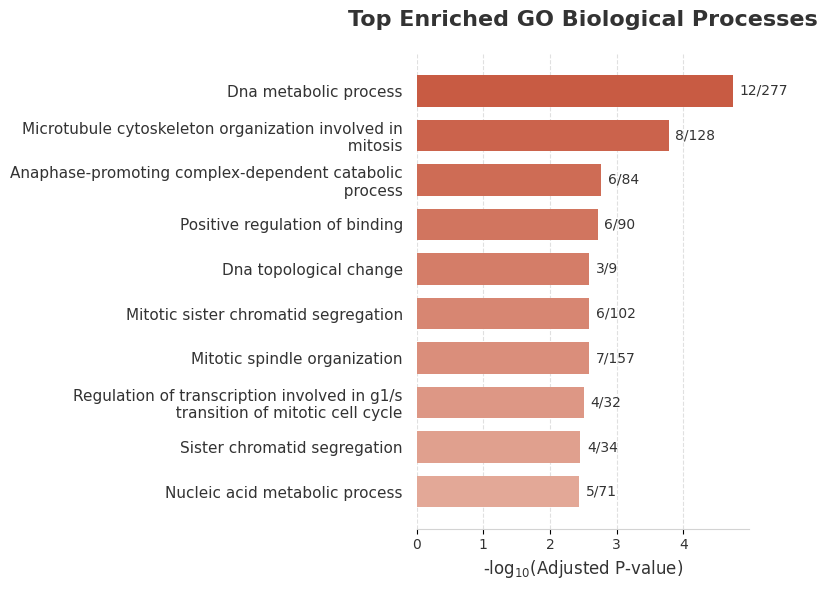

In [33]:
# ==============================
# Import required packages
# ==============================
import os
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# ==============================
# Set working directory
# ==============================
os.chdir("/root/Cycle/Github")
print("Current working directory:", os.getcwd())

# ==============================
# Add HarmoCycle module path
# ==============================
sys.path.append("./HarmoCycle/")

# Import custom functions
from HarmoCycle import *
from Utils import run_comprehensive_enrichment, display_enrichment_results, plot_go_bp_enrichment

# 5. Run comprehensive enrichment analysis using the mapped mouse gene set
enrichment_result = run_comprehensive_enrichment(gene_list=gene_list, organism='Human')

# Display the top 10 enrichment results
display_enrichment_results(enrichment_result, top_n=10)
plot_go_bp_enrichment(enrichment_result, top_n=10, save_path='/root/Cycle/Github/Tutorial/human_close-2017/GO_BP_Enrichment.png')